In [1]:
import matplotlib.pyplot as plt

from srm import catalog
from srm.utils import open_icechunk

var = "pr"
ssp_ens = "008"
g6_ens = "003"
hist_ens = "r3i1p1f1"

# Raw data
raw_data = catalog.get("CESM2-WACCM").to_xarray()

raw_ssp = raw_data["ssp245"][var].sel(ensemble_member=ssp_ens) * 86400
raw_historical = raw_data["historical"][var].sel(ensemble_member=hist_ens) * 86400
raw_g6 = raw_data["g6_1p5k"][var].sel(ensemble_member=g6_ens) * 86400

In [2]:
obs_cache_path = (
    "s3://carbonplan-scratch/srm/bcsd-cache/production/CESM2-WACCM-ERA5-global.icechunk"
)
obs_branch = "v0.11.1"  # scratch/intermediate artifacts always live on "main", per ArtifactCache

coarse_obs = (
    open_icechunk(
        path=obs_cache_path,
        branch=obs_branch,
        group="obs/" + var,
    )[var]
    * 86400
)

In [3]:
ilat = 1.5
ilon = -82.5

train_slice = slice("1978-01-01", "2014-12-31")
fut_slice = slice("2040-01-01", "2069-12-31")

raw_ssp_pt = raw_ssp.sel(lat=ilat, lon=ilon, method="nearest")
raw_g6_pt = raw_g6.sel(lat=ilat, lon=ilon, method="nearest")
raw_historical_pt = raw_historical.sel(lat=ilat, lon=ilon, method="nearest").sel(time=train_slice)
era5_pt = coarse_obs.sel(lat=ilat, lon=ilon, method="nearest").sel(time=train_slice)

In [4]:
from srm.utils import open_icechunk

path_output = "s3://carbonplan-srm/output/production/CESM2-WACCM-ERA5-global.icechunk"
path_qaqc = "/scratch/synced/qa_plots/disagg_checks/"
branch = "v0.11.1"
coarse_debiased_ssp = (
    open_icechunk(
        path=path_output,
        branch=branch,
        group="debiased_coarse/ssp245/" + var + "/" + ssp_ens,
    )[var]
    * 86400
)

coarse_debiased_g6 = (
    open_icechunk(
        path=path_output,
        branch=branch,
        group="debiased_coarse/g6_1p5k/" + var + "/" + g6_ens,
    )[var]
    * 86400
)

coarse_debiased_ssp_pt = coarse_debiased_ssp.sel(lat=ilat, lon=ilon, method="nearest").sel(
    time=fut_slice
)

coarse_debiased_g6_pt = coarse_debiased_g6.sel(lat=ilat, lon=ilon, method="nearest").sel(
    time=fut_slice
)

In [5]:
import pandas as pd

df = pd.DataFrame(
    {
        "raw_historical": raw_historical_pt.to_series(),
        "era5_obs": era5_pt.to_series(),
        "raw_ssp": raw_ssp_pt.to_series(),
        "raw_g6": raw_g6_pt.to_series(),
        "coarse_debiased_ssp": coarse_debiased_ssp_pt.to_series(),
        "coarse_debiased_g6": coarse_debiased_g6_pt.to_series(),
    }
)

df.to_csv("/scratch/synced/notebooks/QA_QC/pr/bug_drilldown_timeseries.csv")

# Do analysis

In [6]:
import point_debias_diagnostic as pdd

In [7]:
import importlib

importlib.reload(pdd)

<module 'point_debias_diagnostic' from '/scratch/synced/notebooks/QA_QC/pr/point_debias_diagnostic.py'>

Text(0.5, 1.0, 'Raw G6')

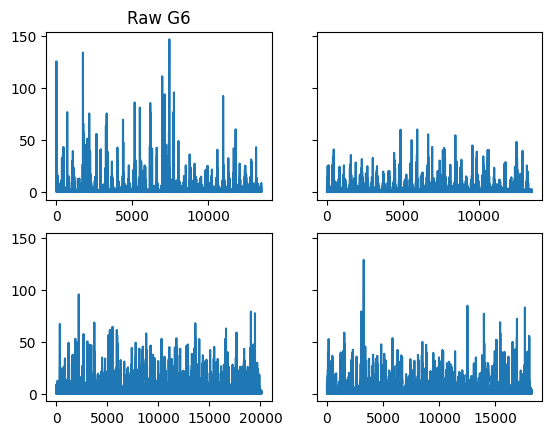

In [8]:
fig, axes = plt.subplots(nrows=2, ncols=2, sharey=True)
axes[0, 0].plot(era5_pt)
axes[0, 0].set_title("Coarsened ERA5")
axes[0, 1].plot(raw_historical_pt)
axes[0, 0].set_title("Raw historical")
axes[1, 0].plot(raw_ssp_pt)
axes[0, 0].set_title("Raw SSP")
axes[1, 1].plot(raw_g6_pt)
axes[0, 0].set_title("Raw G6")

In [9]:
results = pdd.run_analysis(era5_pt, raw_historical_pt, raw_ssp_pt, raw_g6_pt, do_diagnostics=False)

Running nonparametric_hybrid_2sided debiasing (ssp245)...
Running nonparametric_hybrid_2sided debiasing (g6-1.5k)...


# Compare with actual output of pipeline

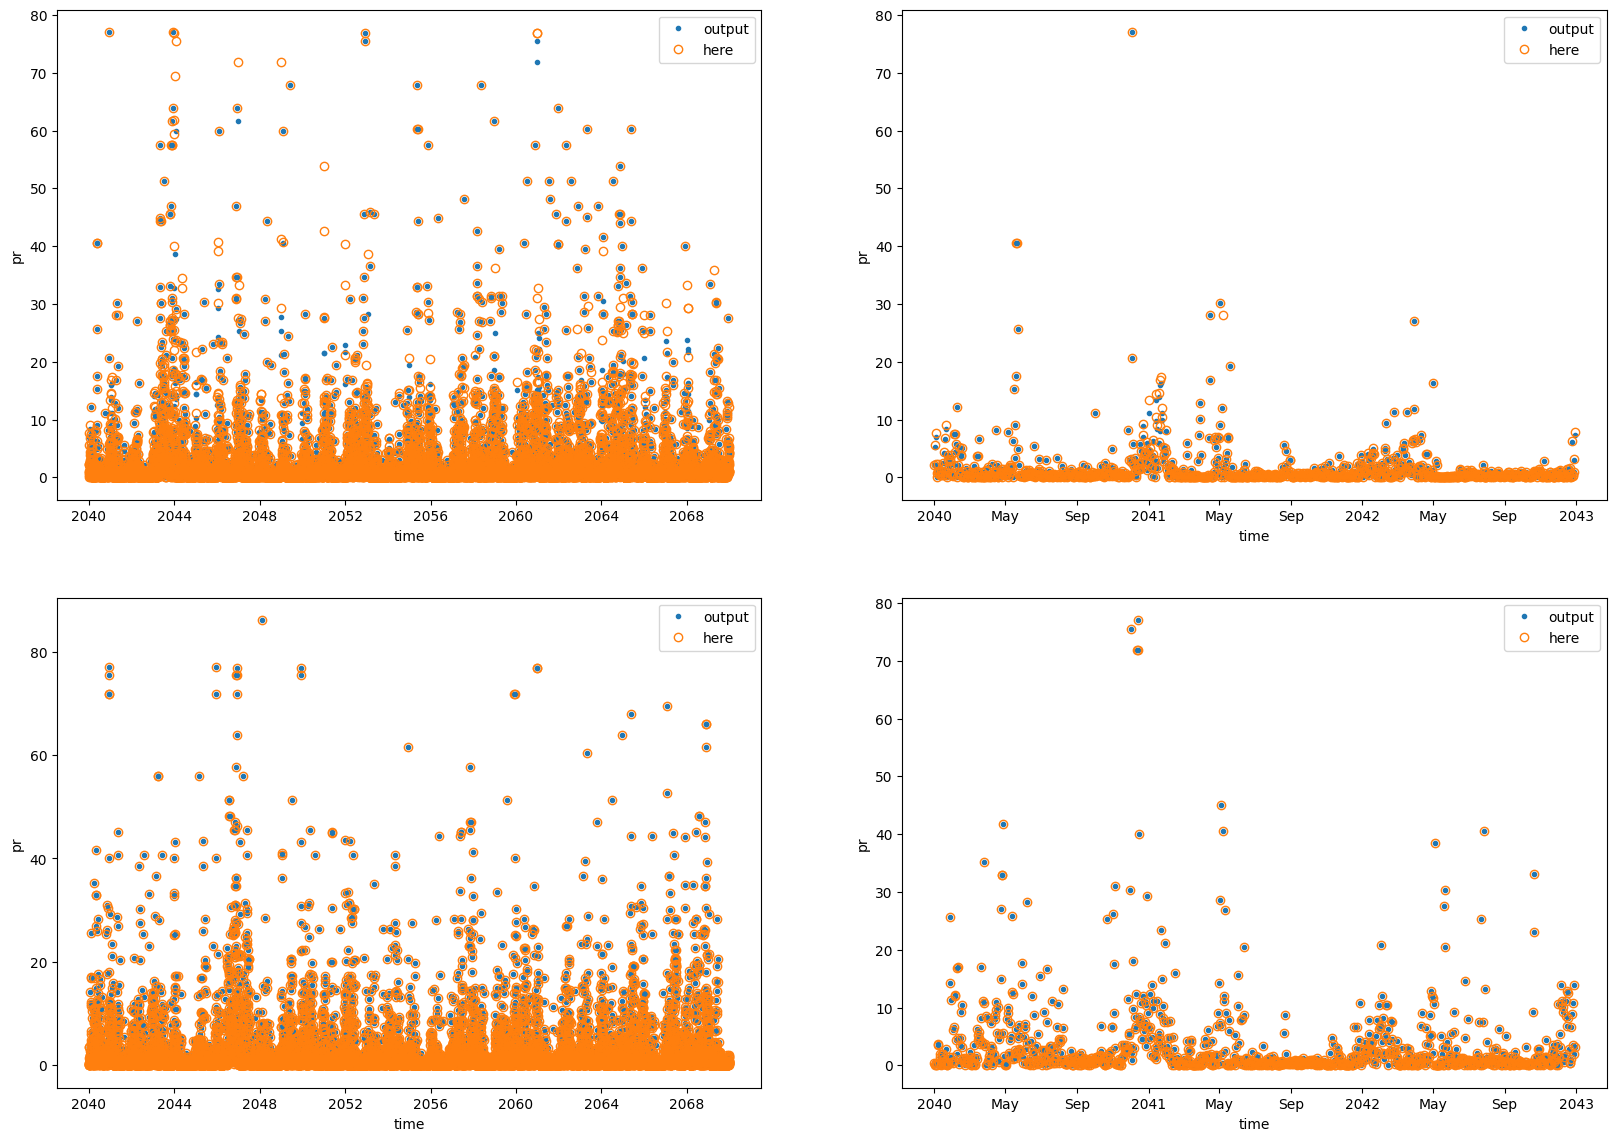

In [10]:
plt.figure(figsize=(20, 14))
plt.subplot(2, 2, 1)
coarse_debiased_g6_pt.plot(label="output", marker=".", linestyle="none")
(results["debiased_g6"]).sel(time=fut_slice).plot(
    label="here", marker="o", fillstyle="none", linestyle="none"
)
plt.legend()

plt.subplot(2, 2, 2)
coarse_debiased_g6_pt[0 : 365 * 3].plot(label="output", marker=".", linestyle="none")
(results["debiased_g6"]).sel(time=fut_slice)[0 : 365 * 3].plot(
    label="here", marker="o", fillstyle="none", linestyle="none"
)
plt.legend()

plt.subplot(2, 2, 3)
coarse_debiased_ssp_pt.plot(label="output", marker=".", linestyle="none")
(results["debiased_ssp"]).sel(time=fut_slice).plot(
    label="here", marker="o", fillstyle="none", linestyle="none"
)
plt.legend()

plt.subplot(2, 2, 4)
coarse_debiased_ssp_pt[0 : 365 * 3].plot(label="output", marker=".", linestyle="none")
(results["debiased_ssp"]).sel(time=fut_slice)[0 : 365 * 3].plot(
    label="here", marker="o", fillstyle="none", linestyle="none"
)
plt.legend()
# plt.plot(raw_ssp_pt.sel(time=fut_slice),coarse_debiased_ssp_pt,'.')

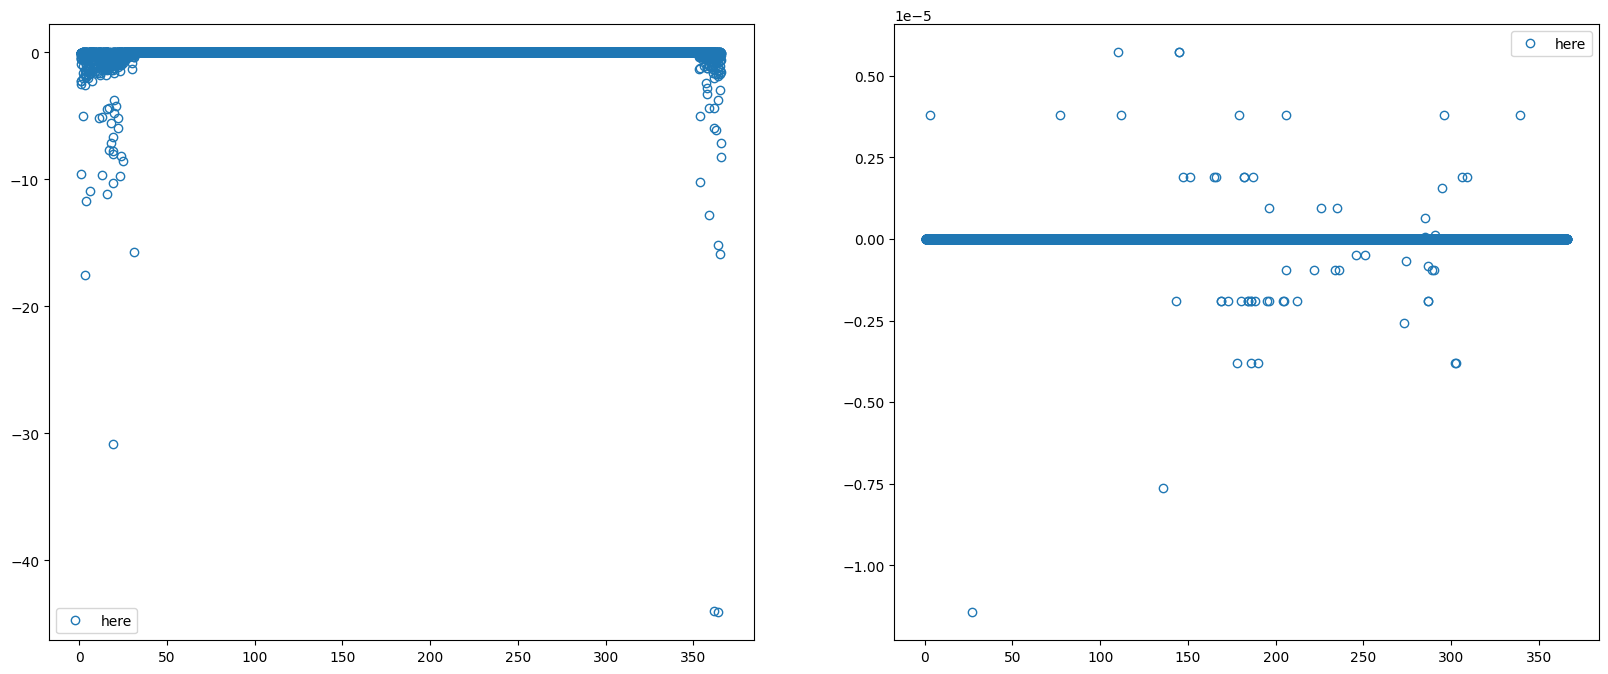

In [11]:
plt.figure(figsize=(20, 8))
plt.subplot(1, 2, 1)
plt.plot(
    coarse_debiased_g6_pt["time.dayofyear"],
    coarse_debiased_g6_pt - (results["debiased_g6"]).sel(time=fut_slice),
    label="here",
    marker="o",
    fillstyle="none",
    linestyle="none",
)
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(
    coarse_debiased_ssp_pt["time.dayofyear"],
    coarse_debiased_ssp_pt - (results["debiased_ssp"]).sel(time=fut_slice),
    label="here",
    marker="o",
    fillstyle="none",
    linestyle="none",
)
plt.legend()

In [12]:
import numpy as np


def compare_to_production(
    name, my_debiased, production_debiased, out_of_range_low=None, out_of_range_high=None
):
    """Compares my_debiased (this script's output) against production_debiased
    (the real coarse_debiased_*_pt you already extracted), aligned on time.
    Breaks the difference down by which branch (nonparametric vs. parametric
    low/high tail) each day went through, if masks are supplied, so we can see
    directly whether the divergence concentrates in the ~99% nonparametric days
    or the <1% parametric days.
    """
    mine, prod = xr.align(my_debiased, production_debiased, join="inner")
    diff = mine - prod
    n = diff.time.size

    print(f"[{name}] {n} overlapping days")
    print(f"  mean(mine):        {float(mine.mean()):.6e}")
    print(f"  mean(production):  {float(prod.mean()):.6e}")
    print(f"  mean(mine - prod): {float(diff.mean()):.6e}")
    print(f"  mine > production: {100 * float((diff > 0).mean()):.1f}% of days")
    print(f"  max |diff|:        {float(np.abs(diff).max()):.6e}")
    print(f"  corr(mine, prod):  {float(xr.corr(mine, prod)):.6f}")

    if out_of_range_low is not None and out_of_range_high is not None:
        low_a, high_a, diff_a = xr.align(out_of_range_low, out_of_range_high, diff, join="inner")
        is_low = low_a & ~high_a
        is_high = high_a
        is_nonparam = ~low_a & ~high_a
        for label, mask in [
            ("nonparametric", is_nonparam),
            ("Weibull low tail", is_low),
            ("Gumbel high tail", is_high),
        ]:
            n_branch = int(mask.sum())
            if n_branch == 0:
                print(f"  {label:18s}: 0 days")
                continue
            branch_mean_diff = float(diff_a.where(mask).mean())
            print(f"  {label:18s}: {n_branch:6d} days, mean(mine - prod) = {branch_mean_diff:+.6e}")

    # monthly breakdown, to see if the bias is seasonal/uniform
    print("  by month:")
    diff_monthly = diff.groupby("time.month").mean()
    for month in range(1, 13):
        val = float(diff_monthly.sel(month=month))
        print(f"    month {month:2d}: mean(mine - prod) = {val:+.6e}")

    return diff

In [13]:
import xarray as xr

diff_ssp = compare_to_production(
    "ssp245",
    results["debiased_ssp"],
    coarse_debiased_ssp_pt,
    results["out_of_range_low_ssp"],
    results["out_of_range_high_ssp"],
)
print()

[ssp245] 10958 overlapping days
  mean(mine):        3.212938e+00
  mean(production):  3.212938e+00
  mean(mine - prod): 1.373360e-09
  mine > production: 0.3% of days
  max |diff|:        1.144409e-05
  corr(mine, prod):  1.000000
  nonparametric     :  10864 days, mean(mine - prod) = +0.000000e+00
  Weibull low tail  :     13 days, mean(mine - prod) = +1.306026e-07
  Gumbel high tail  :     81 days, mean(mine - prod) = +1.648326e-07
  by month:
    month  1: mean(mine - prod) = +8.203650e-09
    month  2: mean(mine - prod) = +1.766390e-16
    month  3: mean(mine - prod) = -4.101825e-09
    month  4: mean(mine - prod) = -1.059638e-08
    month  5: mean(mine - prod) = -6.152737e-09
    month  6: mean(mine - prod) = +4.238553e-09
    month  7: mean(mine - prod) = +1.845804e-08
    month  8: mean(mine - prod) = +1.025456e-09
    month  9: mean(mine - prod) = +3.905863e-09
    month 10: mean(mine - prod) = +9.325947e-09
    month 11: mean(mine - prod) = -4.238553e-09
    month 12: mean(mi

In [ ]:
pt_raw_g6_all = raw_g6.sel(lat=ilat, lon=ilon, method="nearest")
pt_raw_ssp_all = raw_ssp.sel(lat=ilat, lon=ilon, method="nearest")
pt_coarse_debiased_g6_all = coarse_debiased_g6.sel(lat=ilat, lon=ilon, method="nearest")
pt_coarse_debiased_ssp_all = coarse_debiased_ssp.sel(lat=ilat, lon=ilon, method="nearest")

fig, ax = plt.subplots(sharey=True, ncols=2, figsize=(18, 6))
pt_coarse_debiased_g6_all.where(pt_coarse_debiased_g6_all["time.dayofyear"] == 1, drop=True).plot(
    marker="o", fillstyle="none", ax=ax[0], label="Debiased"
)
pt_raw_g6_all.where(pt_raw_g6_all["time.dayofyear"] == 1, drop=True).plot(
    marker=".", ax=ax[0], label="Raw"
)
results["debiased_g6"].where(results["debiased_g6"]["time.dayofyear"] == 1, drop=True).plot(
    marker=".", ax=ax[0], linestyle=":", label="Debiased w/ fix"
)
ax[0].set_title("G6")
ax[0].grid()
ax[0].legend()
ax[0].axhline(y=15, linestyle=":", color="k")
pt_coarse_debiased_ssp_all.where(pt_coarse_debiased_ssp_all["time.dayofyear"] == 1, drop=True).plot(
    marker="o", fillstyle="none", ax=ax[1], label="Debiased"
)
pt_raw_ssp_all.where(pt_raw_ssp_all["time.dayofyear"] == 1, drop=True).plot(
    marker=".", ax=ax[1], label="Raw"
)
results["debiased_ssp"].sel(time=slice("2015-01-01", "2069-12-31")).where(
    results["debiased_ssp"]["time.dayofyear"] == 1, drop=True
).plot(marker=".", ax=ax[1], linestyle=":", label="Debiased w/ fix")

ax[1].set_title("SSP")
ax[1].axhline(y=15, linestyle=":", color="k")
ax[1].grid()
ax[1].legend()